# Probability & Statistics Foundations for Quantitative Finance

This notebook covers the core probability and statistics concepts that underpin quantitative finance. The goal is rigour without ceremony — definitions are precise, but the emphasis is on building intuition and seeing how each concept shows up in markets.

**Roadmap**

1. Probability fundamentals
2. Random variables, PMF / PDF / CDF
3. Moments — expectation, variance, skewness, kurtosis
4. Key distributions and their finance roles
5. Joint distributions, covariance, and correlation
6. The Central Limit Theorem
7. Statistical inference — MLE, confidence intervals, hypothesis testing
8. Finance application: log-returns, fat tails, VaR / CVaR

In [1]:
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

---
## 1  Probability Fundamentals

### 1.1  Kolmogorov Axioms

A **probability space** is a triple $(\Omega, \mathcal{F}, P)$:
- $\Omega$ — sample space (all possible outcomes)
- $\mathcal{F}$ — a $\sigma$-algebra of events (subsets of $\Omega$ we can assign probability to)
- $P : \mathcal{F} \to [0,1]$ — a probability measure satisfying:
  1. $P(A) \ge 0$ for all $A \in \mathcal{F}$
  2. $P(\Omega) = 1$
  3. For disjoint $A_1, A_2, \ldots$: $P\!\left(\bigcup_i A_i\right) = \sum_i P(A_i)$

Everything else follows from these three axioms.

### 1.2  Conditional Probability

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

Intuition: restricting the sample space to $B$ and re-normalising.

### 1.3  Bayes' Theorem

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

Allows us to **update** a prior belief $P(A)$ after observing evidence $B$. The backbone of Bayesian inference.

### 1.4  Total Probability

If $\{A_i\}$ is a partition of $\Omega$:
$$P(B) = \sum_i P(B \mid A_i)\, P(A_i)$$

### 1.5  Independence

$A$ and $B$ are **independent** if $P(A \cap B) = P(A)\,P(B)$, which implies $P(A \mid B) = P(A)$.

> **Finance note.** Assuming return independence across assets is a core (and often violated) hypothesis in portfolio theory.

In [2]:
# Bayes' theorem: classic base-rate example
# A signal predicts a market crash with sensitivity 0.9 and false-positive rate 0.05.
# Market crashes happen 2% of the time.  What is the probability of a crash given the signal fires?

p_crash = 0.02          # prior
p_signal_given_crash = 0.90   # sensitivity (true positive rate)
p_signal_given_no_crash = 0.05  # false positive rate

p_no_crash = 1 - p_crash
p_signal = p_signal_given_crash * p_crash + p_signal_given_no_crash * p_no_crash

p_crash_given_signal = (p_signal_given_crash * p_crash) / p_signal

print(f"P(signal fires)              = {p_signal:.4f}")
print(f"P(crash | signal fires)      = {p_crash_given_signal:.4f}")
print()
print("Despite a 90% sensitive signal, most alarms are false positives")
print("because crashes are so rare — classic base-rate neglect.")

P(signal fires)              = 0.0670
P(crash | signal fires)      = 0.2687

Despite a 90% sensitive signal, most alarms are false positives
because crashes are so rare — classic base-rate neglect.


---
## 2  Random Variables, PMF / PDF / CDF

A **random variable** $X : \Omega \to \mathbb{R}$ maps outcomes to real numbers.

| | Discrete | Continuous |
|---|---|---|
| Mass / Density | PMF $p(x) = P(X = x)$ | PDF $f(x)$, where $P(a < X \le b) = \int_a^b f(x)\,dx$ |
| Normalisation | $\sum_x p(x) = 1$ | $\int_{-\infty}^{\infty} f(x)\,dx = 1$ |
| CDF | $F(x) = \sum_{t \le x} p(t)$ | $F(x) = \int_{-\infty}^x f(t)\,dt$ |

The CDF $F(x) = P(X \le x)$ is always right-continuous and non-decreasing from 0 to 1.

The **quantile function** (inverse CDF) $F^{-1}(q)$ is central to risk measures: Value-at-Risk is simply a quantile of the loss distribution.

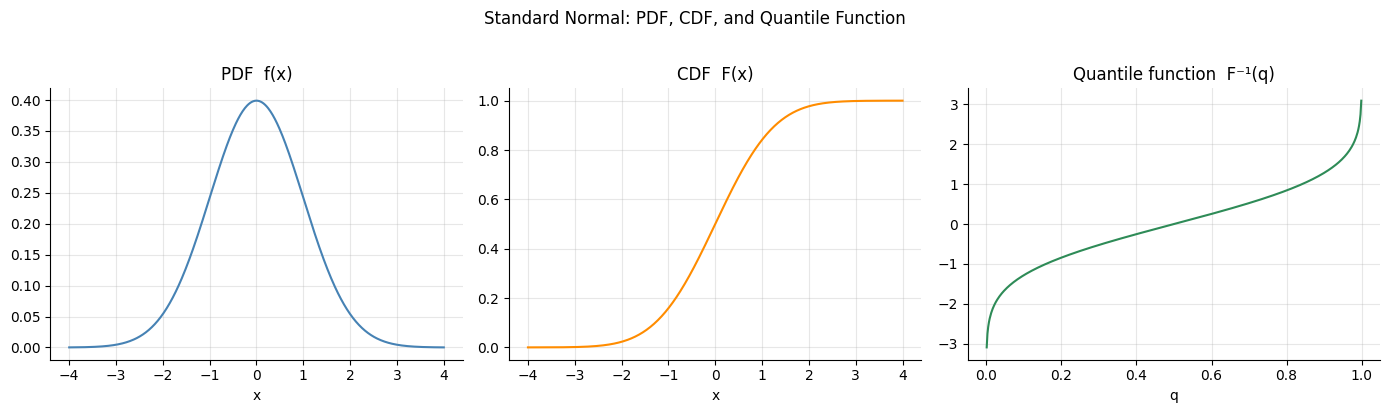

In [3]:
x = np.linspace(-4, 4, 500)
norm = stats.norm(loc=0, scale=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x, norm.pdf(x), color="steelblue")
axes[0].set_title("PDF  f(x)")
axes[0].set_xlabel("x")

axes[1].plot(x, norm.cdf(x), color="darkorange")
axes[1].set_title("CDF  F(x)")
axes[1].set_xlabel("x")

q = np.linspace(0.001, 0.999, 500)
axes[2].plot(q, norm.ppf(q), color="seagreen")
axes[2].set_title("Quantile function  F⁻¹(q)")
axes[2].set_xlabel("q")

fig.suptitle("Standard Normal: PDF, CDF, and Quantile Function", y=1.02)
plt.tight_layout()
plt.show()

---
## 3  Moments

Moments summarise the shape of a distribution.

### 3.1  Expectation

$$E[X] = \int_{-\infty}^{\infty} x\, f(x)\,dx \qquad (\text{continuous})$$

**Linearity:** $E[aX + bY] = a\,E[X] + b\,E[Y]$ — holds regardless of dependence.

### 3.2  Variance and Standard Deviation

$$\text{Var}(X) = E[(X - \mu)^2] = E[X^2] - \mu^2, \qquad \sigma = \sqrt{\text{Var}(X)}$$

In finance, $\sigma$ is **volatility** — the most fundamental risk measure.

### 3.3  Skewness

$$\text{Skew}(X) = E\!\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$$

- Positive skew: long right tail (e.g. venture returns).
- Negative skew: long left tail — common for equity index returns (crash risk).

### 3.4  Excess Kurtosis

$$\text{Kurt}(X) = E\!\left[\left(\frac{X-\mu}{\sigma}\right)^4\right] - 3$$

The $-3$ centres on the Normal (which has kurtosis 3). **Leptokurtic** distributions (excess kurtosis $> 0$) have fatter tails than Normal — a near-universal feature of financial return data.

In [4]:
# Simulate and compute moments for a skewed distribution
alpha = 5.0  # shape parameter for chi-squared-like skewed distribution
samples = rng.standard_gamma(alpha, size=100_000)
# Standardise to zero mean / unit variance for comparison
s = (samples - samples.mean()) / samples.std()

mean_s = s.mean()
var_s = s.var()
skew_s = stats.skew(s)
kurt_s = stats.kurtosis(s)  # excess kurtosis by default in scipy

print(f"Mean:             {mean_s:+.6f}  (theoretical: 0)")
print(f"Variance:         {var_s:.6f}  (theoretical: 1)")
print(f"Skewness:         {skew_s:+.4f}  (theoretical: {2/math.sqrt(alpha):.4f})")
print(f"Excess kurtosis:  {kurt_s:+.4f}  (theoretical: {6/alpha:.4f})")

Mean:             +0.000000  (theoretical: 0)
Variance:         1.000000  (theoretical: 1)
Skewness:         +0.9105  (theoretical: 0.8944)
Excess kurtosis:  +1.2862  (theoretical: 1.2000)


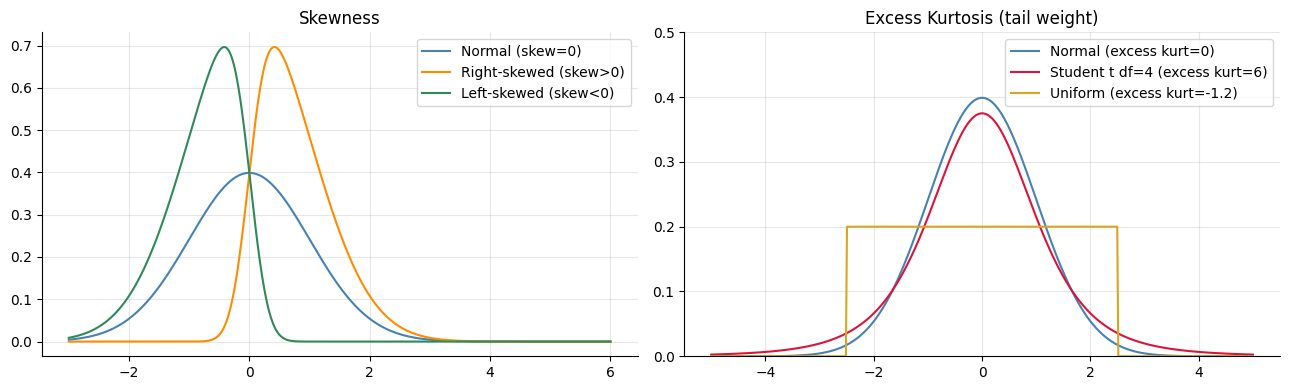

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Skewness comparison
x = np.linspace(-3, 6, 500)
axes[0].plot(x, stats.norm.pdf(x), label="Normal (skew=0)", color="steelblue")
axes[0].plot(x, stats.skewnorm.pdf(x, a=4), label="Right-skewed (skew>0)", color="darkorange")
axes[0].plot(x, stats.skewnorm.pdf(x, a=-4), label="Left-skewed (skew<0)", color="seagreen")
axes[0].set_title("Skewness")
axes[0].legend()

# Kurtosis comparison
x = np.linspace(-5, 5, 500)
axes[1].plot(x, stats.norm.pdf(x), label="Normal (excess kurt=0)", color="steelblue")
axes[1].plot(x, stats.t.pdf(x, df=4), label="Student t df=4 (excess kurt=6)", color="crimson")
axes[1].plot(x, stats.uniform.pdf(x, -2.5, 5), label="Uniform (excess kurt=-1.2)", color="goldenrod")
axes[1].set_ylim(0, 0.5)
axes[1].set_title("Excess Kurtosis (tail weight)")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4  Key Distributions and Their Finance Roles

### 4.1  Discrete Distributions

| Distribution | PMF | Mean | Variance | Finance use |
|---|---|---|---|---|
| Bernoulli($p$) | $p^k(1-p)^{1-k}$, $k\in\{0,1\}$ | $p$ | $p(1-p)$ | Default / no-default |
| Binomial($n,p$) | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | Count of defaults in a pool |
| Poisson($\lambda$) | $e^{-\lambda}\lambda^k/k!$ | $\lambda$ | $\lambda$ | Arrival of trades, news events |

### 4.2  Continuous Distributions

| Distribution | Parameters | Mean | Variance | Finance use |
|---|---|---|---|---|
| Uniform($a,b$) | $a < b$ | $(a+b)/2$ | $(b-a)^2/12$ | Simulation baseline |
| Normal($\mu,\sigma^2$) | — | $\mu$ | $\sigma^2$ | Returns approximation, risk |
| Log-Normal($\mu,\sigma^2$) | — | $e^{\mu+\sigma^2/2}$ | $(e^{\sigma^2}-1)e^{2\mu+\sigma^2}$ | **Price levels** (GBM) |
| Student $t$($\nu$) | df $\nu > 0$ | 0 (if $\nu>1$) | $\nu/(\nu-2)$ (if $\nu>2$) | **Fat-tailed returns**, VaR |
| Exponential($\lambda$) | rate $\lambda > 0$ | $1/\lambda$ | $1/\lambda^2$ | Time between events (jumps) |
| Chi-squared($k$) | df $k > 0$ | $k$ | $2k$ | Variance estimation, LRT |
| Beta($\alpha,\beta$) | shape params | $\alpha/(\alpha+\beta)$ | — | Default probability modelling |

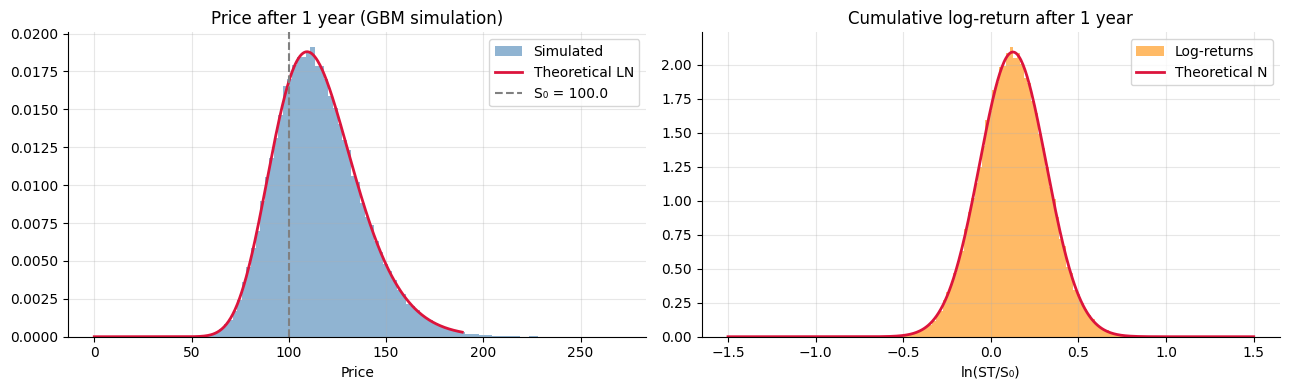

Theoretical E[ST]  = 115.51
Simulated   E[ST]  = 115.54


In [6]:
# --- Log-Normal: why prices must be log-normally distributed under GBM ---
# If daily log-returns are i.i.d. Normal, price after T days is log-normally distributed.

mu_r = 0.0005    # daily log-return mean
sigma_r = 0.012  # daily volatility
T = 252          # trading days
S0 = 100.0

# Simulate final prices
log_returns = rng.normal(mu_r, sigma_r, size=(100_000, T))
log_ST = np.log(S0) + log_returns.sum(axis=1)
ST = np.exp(log_ST)

# Theoretical log-normal parameters
mu_log = np.log(S0) + mu_r * T
sigma_log = sigma_r * math.sqrt(T)
ln_dist = stats.lognorm(s=sigma_log, scale=math.exp(mu_log))

x = np.linspace(0, ST.max() * 0.7, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ST, bins=100, density=True, alpha=0.6, color="steelblue", label="Simulated")
axes[0].plot(x, ln_dist.pdf(x), color="crimson", linewidth=2, label="Theoretical LN")
axes[0].axvline(S0, color="grey", linestyle="--", label=f"S₀ = {S0}")
axes[0].set_title("Price after 1 year (GBM simulation)")
axes[0].set_xlabel("Price")
axes[0].legend()

axes[1].hist(log_ST - np.log(S0), bins=100, density=True, alpha=0.6, color="darkorange", label="Log-returns")
x2 = np.linspace(-1.5, 1.5, 500)
axes[1].plot(x2, stats.norm.pdf(x2, mu_r * T, sigma_log), color="crimson", linewidth=2, label="Theoretical N")
axes[1].set_title("Cumulative log-return after 1 year")
axes[1].set_xlabel("ln(ST/S₀)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Theoretical E[ST]  = {ln_dist.mean():.2f}")
print(f"Simulated   E[ST]  = {ST.mean():.2f}")

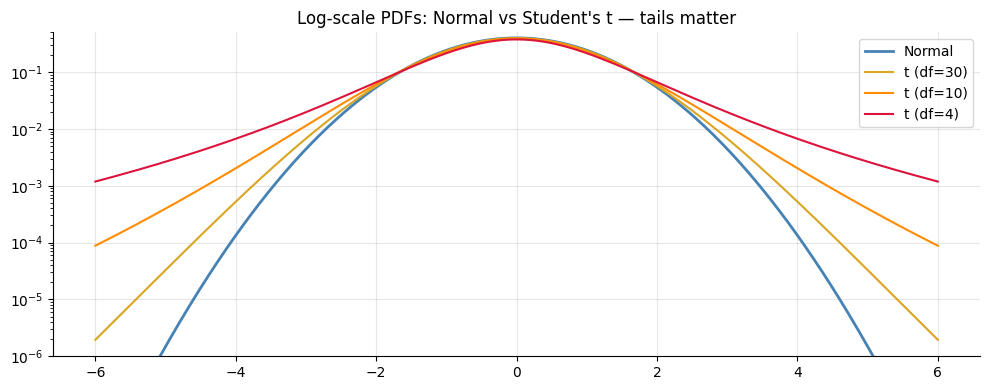

  t(df=   4) P(|X|>3σ) = 0.03994  (14.8x Normal)
  t(df=  10) P(|X|>3σ) = 0.01334  (4.9x Normal)
  t(df=  30) P(|X|>3σ) = 0.00539  (2.0x Normal)
  t(df=1000) P(|X|>3σ) = 0.00277  (1.0x Normal)
  Normal    P(|X|>3σ) = 0.00270


In [7]:
# --- Student's t: fat tails matter for risk ---
fig, ax = plt.subplots(figsize=(10, 4))

x = np.linspace(-6, 6, 600)
ax.plot(x, stats.norm.pdf(x), label="Normal", color="steelblue", linewidth=2)
for df, col in [(30, "goldenrod"), (10, "darkorange"), (4, "crimson")]:
    ax.plot(x, stats.t.pdf(x, df=df), label=f"t (df={df})", color=col, linewidth=1.5)

ax.set_yscale("log")
ax.set_ylim(1e-6, 0.5)
ax.set_title("Log-scale PDFs: Normal vs Student's t — tails matter")
ax.legend()
plt.tight_layout()
plt.show()

# Tail probability comparison at 3-sigma
threshold = 3.0
for df in [4, 10, 30, 1000]:
    p_t = 2 * stats.t.sf(threshold, df=df)
    p_n = 2 * stats.norm.sf(threshold)
    ratio = p_t / p_n
    print(f"  t(df={df:4d}) P(|X|>3σ) = {p_t:.5f}  ({ratio:.1f}x Normal)")
print(f"  Normal    P(|X|>3σ) = {p_n:.5f}")

---
## 5  Joint Distributions, Covariance, and Correlation

### 5.1  Joint and Marginal Distributions

For two continuous RVs $(X, Y)$ with joint PDF $f_{X,Y}(x,y)$:

$$f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy \quad \text{(marginal)}$$

$$f_{Y|X}(y \mid x) = \frac{f_{X,Y}(x,y)}{f_X(x)} \quad \text{(conditional)}$$

### 5.2  Covariance and Correlation

$$\text{Cov}(X,Y) = E[(X-\mu_X)(Y-\mu_Y)] = E[XY] - \mu_X \mu_Y$$

$$\rho_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

**Portfolio variance:** for weights $w_i$ and assets with covariance matrix $\Sigma$:

$$\sigma_p^2 = \mathbf{w}^\top \Sigma\, \mathbf{w}$$

Correlation determines diversification benefit — the key insight behind mean-variance optimisation.

### 5.3  Independence vs. Uncorrelated

Independence $\Rightarrow$ uncorrelated, but **uncorrelated $\not\Rightarrow$ independent** (except for jointly normal variables).

This matters: two assets can have zero linear correlation but still co-move in crashes (tail dependence).

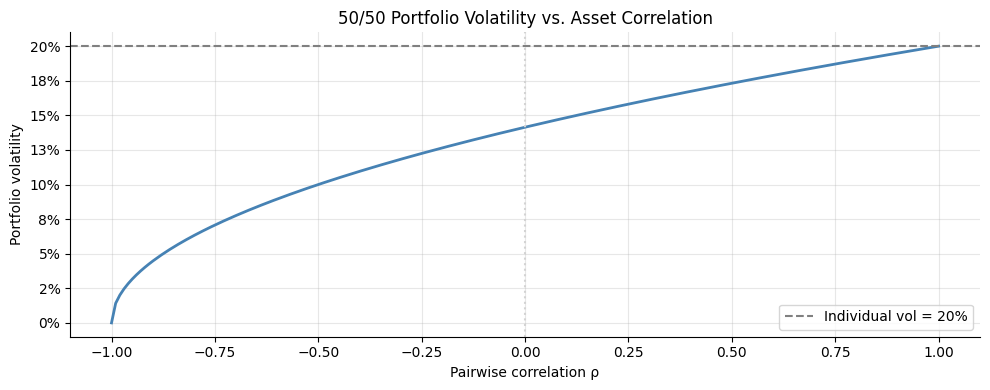

At ρ = -1 : portfolio vol = 0.00%  (maximum diversification)
At ρ =  0 : portfolio vol = 14.18%
At ρ = +1 : portfolio vol = 20.00%  (no diversification benefit)


In [8]:
# Portfolio variance as a function of pairwise correlation
n_assets = 2
sigma1 = sigma2 = 0.20  # 20% annual vol each

rhos = np.linspace(-1, 1, 200)
w = np.array([0.5, 0.5])

port_vols = []
for rho in rhos:
    cov_matrix = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2],
    ])
    port_var = w @ cov_matrix @ w
    port_vols.append(math.sqrt(port_var))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rhos, port_vols, color="steelblue", linewidth=2)
ax.axhline(sigma1, color="grey", linestyle="--", label=f"Individual vol = {sigma1:.0%}")
ax.axvline(0, color="lightgrey", linestyle=":")
ax.set_xlabel("Pairwise correlation ρ")
ax.set_ylabel("Portfolio volatility")
ax.set_title("50/50 Portfolio Volatility vs. Asset Correlation")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"At ρ = -1 : portfolio vol = {port_vols[0]:.2%}  (maximum diversification)")
print(f"At ρ =  0 : portfolio vol = {port_vols[100]:.2%}")
print(f"At ρ = +1 : portfolio vol = {port_vols[-1]:.2%}  (no diversification benefit)")

Corr(X, Y) = -0.0254  (near zero)
But clearly Y is determined by X — correlation only captures LINEAR dependence.


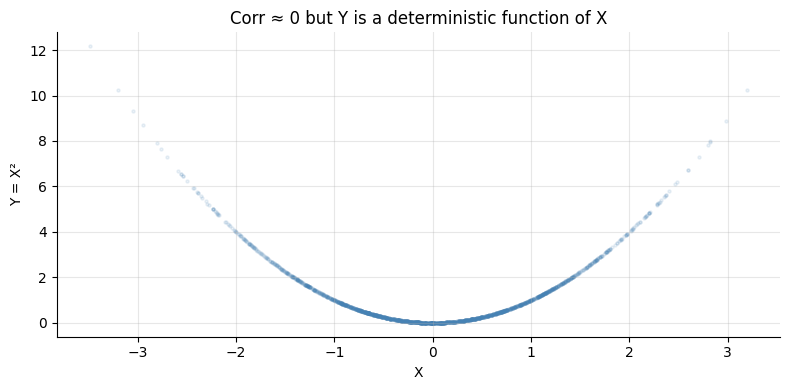

In [9]:
# Uncorrelated ≠ Independent: X ~ N(0,1), Y = X² — zero correlation, strong dependence
X = rng.standard_normal(10_000)
Y = X**2

print(f"Corr(X, Y) = {np.corrcoef(X, Y)[0, 1]:.4f}  (near zero)")
print("But clearly Y is determined by X — correlation only captures LINEAR dependence.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X[:2000], Y[:2000], alpha=0.1, s=5, color="steelblue")
ax.set_xlabel("X")
ax.set_ylabel("Y = X²")
ax.set_title("Corr ≈ 0 but Y is a deterministic function of X")
plt.tight_layout()
plt.show()

---
## 6  The Central Limit Theorem

**Theorem (CLT).** Let $X_1, X_2, \ldots$ be i.i.d. with mean $\mu$ and variance $\sigma^2 < \infty$. Then:

$$\frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1) \quad \text{as } n \to \infty$$

The CLT is why:
- Sample means are approximately normal even when the underlying distribution is not.
- Portfolio returns (sums of many small positions) trend toward normality — though tail events break this.
- Standard errors, confidence intervals, and t-tests all rely on it.

**Caveat for finance:** the CLT requires finite variance. Heavy-tailed distributions (stable distributions, $\alpha$-stable with $\alpha < 2$) do not satisfy this and converge to a stable law instead.

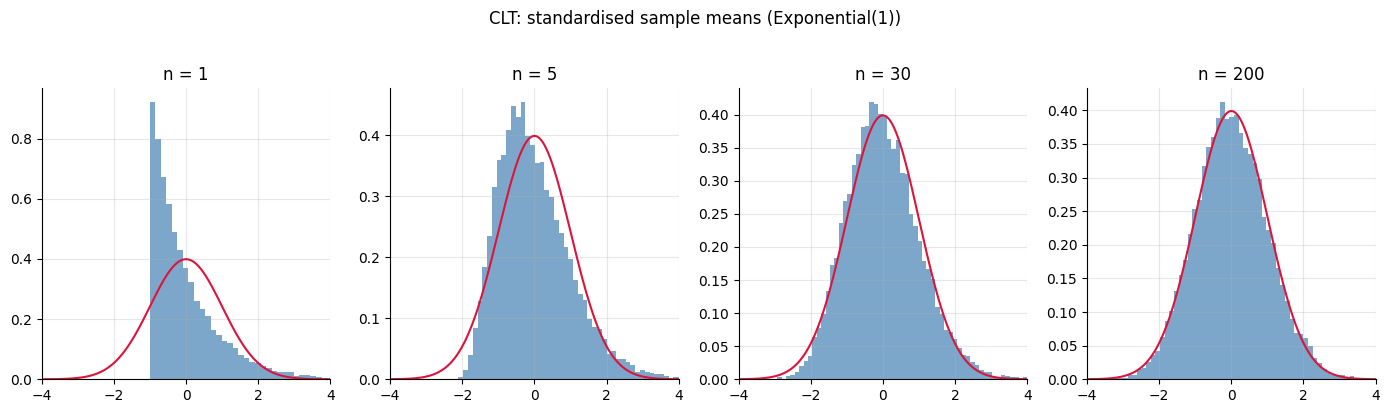

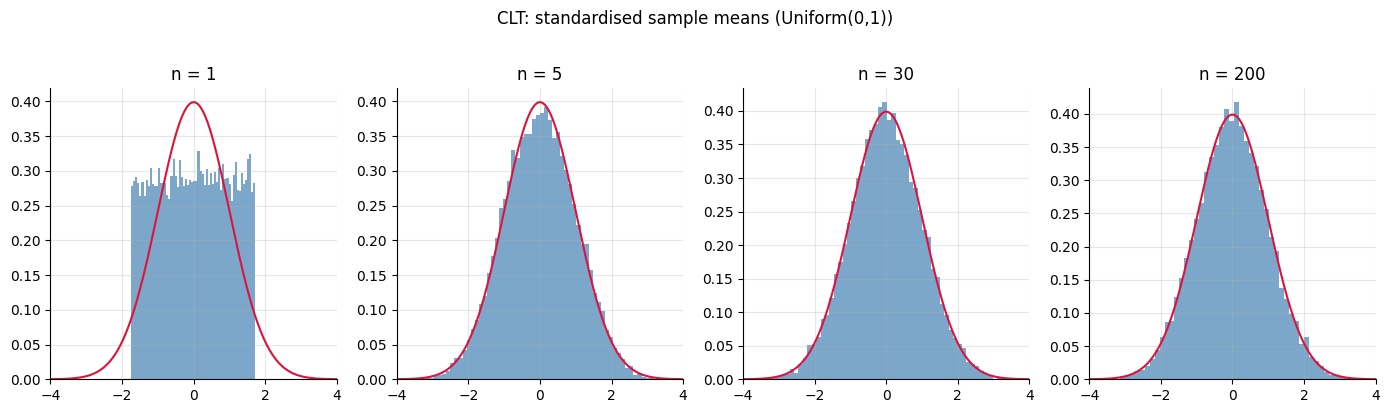

In [10]:
def demonstrate_clt(dist_samples_fn: callable, dist_name: str, n_values: list[int], n_trials: int = 20_000) -> None:
    fig, axes = plt.subplots(1, len(n_values), figsize=(14, 4), sharey=False)
    x = np.linspace(-4, 4, 400)

    for ax, n in zip(axes, n_values):
        data = dist_samples_fn(size=(n_trials, n))
        means = data.mean(axis=1)
        standardised = (means - means.mean()) / means.std()
        ax.hist(standardised, bins=60, density=True, alpha=0.7, color="steelblue")
        ax.plot(x, stats.norm.pdf(x), color="crimson", linewidth=1.5)
        ax.set_title(f"n = {n}")
        ax.set_xlim(-4, 4)

    fig.suptitle(f"CLT: standardised sample means ({dist_name})", y=1.02)
    plt.tight_layout()
    plt.show()

# Heavy-tailed exponential — converges but needs larger n
demonstrate_clt(
    lambda size: rng.exponential(scale=1.0, size=size),
    "Exponential(1)",
    n_values=[1, 5, 30, 200],
)

# Uniform — converges very quickly
demonstrate_clt(
    lambda size: rng.uniform(0, 1, size=size),
    "Uniform(0,1)",
    n_values=[1, 5, 30, 200],
)

---
## 7  Statistical Inference

### 7.1  Maximum Likelihood Estimation (MLE)

Given observations $x_1, \ldots, x_n$ and a parametric model $f(x; \theta)$, MLE finds:

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \sum_{i=1}^n \ln f(x_i; \theta)$$

MLE is **consistent** and **asymptotically efficient** (achieves the Cramér-Rao lower bound).

### 7.2  Confidence Intervals

A $95\%$ CI for $\mu$ (known $\sigma$, large $n$):

$$\bar{X} \pm z_{0.975} \cdot \frac{\sigma}{\sqrt{n}}$$

Interpretation: if we repeated the procedure, $95\%$ of such intervals would contain the true $\mu$. **It is NOT "95% probability that $\mu$ is in this interval"** — $\mu$ is fixed, not random.

### 7.3  Hypothesis Testing

**Setup:**
- $H_0$ (null hypothesis): e.g., strategy return $= 0$
- $H_1$ (alternative): return $\ne 0$
- Choose significance level $\alpha$ (Type I error probability) before seeing data

**p-value:** probability of observing a test statistic at least as extreme as the observed one, *assuming $H_0$ is true*.

Reject $H_0$ when $p < \alpha$. The p-value is **not** the probability $H_0$ is true.

**One-sample t-test** (unknown $\sigma$):
$$t = \frac{\bar{X} - \mu_0}{s / \sqrt{n}} \sim t(n-1) \text{ under } H_0$$

In [11]:
# MLE for Normal distribution parameters
true_mu, true_sigma = 0.05, 0.20
n = 250
data = rng.normal(true_mu, true_sigma, size=n)

# MLE: for Normal, closed-form solutions are sample mean and biased std
mu_mle = data.mean()
sigma_mle = data.std(ddof=0)  # MLE uses n in denominator
sigma_unbiased = data.std(ddof=1)  # unbiased estimator uses n-1

print("MLE for Normal(μ, σ²)")
print(f"  True μ = {true_mu:.4f}   MLE μ̂ = {mu_mle:.4f}")
print(f"  True σ = {true_sigma:.4f}   MLE σ̂ = {sigma_mle:.4f}  (biased)")
print(f"                           Unbiased σ̂ = {sigma_unbiased:.4f}")

# scipy also provides fit() for MLE
mu_fit, sigma_fit = stats.norm.fit(data)
print(f"\nscipy norm.fit():  μ̂ = {mu_fit:.4f}, σ̂ = {sigma_fit:.4f}")

MLE for Normal(μ, σ²)
  True μ = 0.0500   MLE μ̂ = 0.0470
  True σ = 0.2000   MLE σ̂ = 0.2131  (biased)
                           Unbiased σ̂ = 0.2136

scipy norm.fit():  μ̂ = 0.0470, σ̂ = 0.2131


In [12]:
# Confidence interval for the mean
alpha = 0.05
se = sigma_unbiased / math.sqrt(n)
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
ci_low = mu_mle - t_crit * se
ci_high = mu_mle + t_crit * se

print(f"95% CI for μ: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"True μ = {true_mu:.4f}  →  {'inside' if ci_low < true_mu < ci_high else 'OUTSIDE'} the CI")

# Coverage simulation: how often does the 95% CI contain the true mean?
n_sims = 10_000
inside = 0
for _ in range(n_sims):
    samp = rng.normal(true_mu, true_sigma, size=n)
    m, s = samp.mean(), samp.std(ddof=1)
    lo = m - t_crit * s / math.sqrt(n)
    hi = m + t_crit * s / math.sqrt(n)
    if lo < true_mu < hi:
        inside += 1

print(f"\nEmpirical coverage over {n_sims:,} simulations: {inside/n_sims:.3%}  (nominal: 95%)")

95% CI for μ: [0.0204, 0.0736]
True μ = 0.0500  →  inside the CI

Empirical coverage over 10,000 simulations: 94.970%  (nominal: 95%)


In [16]:
# One-sample t-test: is a strategy's mean return significantly different from zero?
strategy_returns = rng.normal(loc=0.0003, scale=0.015, size=252)  # daily returns, ~7.5bp daily edge

t_stat, p_value = stats.ttest_1samp(strategy_returns, popmean=0.0)
mean_ann = strategy_returns.mean() * 252
vol_ann = strategy_returns.std(ddof=1) * math.sqrt(252)
sharpe = mean_ann / vol_ann

print("One-sample t-test: H₀: μ = 0")
print(f"  Annualised mean return : {mean_ann:.2%}")
print(f"  Annualised volatility  : {vol_ann:.2%}")
print(f"  Sharpe ratio           : {sharpe:.2f}")
print(f"  t-statistic            : {t_stat:.3f}")
print(f"  p-value                : {p_value:.4f}")
print(f"  Reject H₀ at 5%?       : {p_value < 0.05}")

One-sample t-test: H₀: μ = 0
  Annualised mean return : 16.93%
  Annualised volatility  : 23.65%
  Sharpe ratio           : 0.72
  t-statistic            : 0.716
  p-value                : 0.4747
  Reject H₀ at 5%?       : False


---
## 8  Finance Application: Log-Returns, Fat Tails, VaR & CVaR

### 8.1  Log-Returns

Simple returns: $R_t = (P_t - P_{t-1}) / P_{t-1}$  
Log-returns: $r_t = \ln(P_t / P_{t-1}) = \ln(1 + R_t)$

Log-returns are preferred because:
1. **Time-additivity**: $r_1 + r_2 + \cdots + r_T = \ln(P_T / P_0)$
2. **Stationarity**: more natural to model as a stationary series
3. **Symmetry**: a $-50\%$ log-return requires $+100\%$ log-return to recover (vs $\pm 50\%$ simple)

### 8.2  Value-at-Risk (VaR) and Conditional VaR (CVaR)

$$\text{VaR}_\alpha = -F^{-1}(\alpha)$$

where $F$ is the CDF of portfolio returns and $\alpha$ is the loss confidence level (e.g., $1\%$).

$\text{VaR}_{1\%}$ = the loss that is exceeded only $1\%$ of the time.

**CVaR** (Expected Shortfall): the expected loss *given* it exceeds VaR:

$$\text{CVaR}_\alpha = -E[R \mid R \le -\text{VaR}_\alpha]$$

CVaR is a **coherent** risk measure (VaR is not) and captures the severity of tail losses, not just their threshold.

In [17]:
# Empirical VaR and CVaR — compare Normal assumption vs fat-tailed t(4)
n_sim = 500_000
alpha = 0.01  # 1% VaR

daily_mu = 0.0
daily_sigma = 0.015  # 1.5% daily vol

# Normal returns
r_normal = rng.normal(daily_mu, daily_sigma, size=n_sim)

# Student-t returns with same mean and vol (df=4 → heavy tails)
df_t = 4
scale_t = daily_sigma * math.sqrt((df_t - 2) / df_t)  # adjust scale so Var matches
r_t = stats.t.rvs(df=df_t, loc=daily_mu, scale=scale_t, size=n_sim, random_state=rng)

def compute_var_cvar(returns: np.ndarray, alpha: float) -> tuple[float, float]:
    var = -np.quantile(returns, alpha)
    cvar = -returns[returns <= -var].mean()
    return var, cvar

var_n, cvar_n = compute_var_cvar(r_normal, alpha)
var_t, cvar_t = compute_var_cvar(r_t, alpha)

# Analytical VaR for Normal
var_n_theoretical = -stats.norm.ppf(alpha, loc=daily_mu, scale=daily_sigma)

print(f"1% Daily VaR / CVaR  (σ = {daily_sigma:.1%} for both)")
print(f"  Normal:    VaR = {var_n:.3%}   CVaR = {cvar_n:.3%}   (theoretical VaR: {var_n_theoretical:.3%})")
print(f"  Student-t: VaR = {var_t:.3%}   CVaR = {cvar_t:.3%}")
print()
print(f"Fat tails inflate CVaR by {cvar_t/cvar_n - 1:.1%} vs Normal — tail severity is systematically underestimated.")

1% Daily VaR / CVaR  (σ = 1.5% for both)
  Normal:    VaR = 3.517%   CVaR = 4.019%   (theoretical VaR: 3.490%)
  Student-t: VaR = 3.961%   CVaR = 5.529%

Fat tails inflate CVaR by 37.6% vs Normal — tail severity is systematically underestimated.


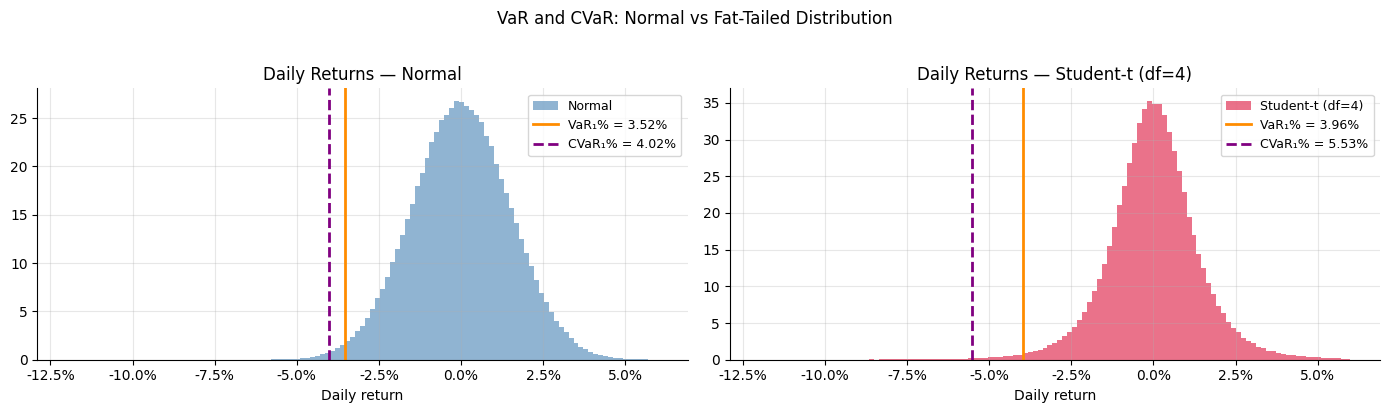

In [18]:
# Visual comparison: Normal vs t tail loss distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = np.linspace(-0.12, 0.06, 120)

for ax, returns, label, color, var, cvar in [
    (axes[0], r_normal, "Normal", "steelblue", var_n, cvar_n),
    (axes[1], r_t, "Student-t (df=4)", "crimson", var_t, cvar_t),
]:
    ax.hist(returns, bins=bins, density=True, color=color, alpha=0.6, label=label)
    ax.axvline(-var, color="darkorange", linewidth=2, label=f"VaR₁% = {var:.2%}")
    ax.axvline(-cvar, color="purple", linewidth=2, linestyle="--", label=f"CVaR₁% = {cvar:.2%}")
    ax.set_title(f"Daily Returns — {label}")
    ax.set_xlabel("Daily return")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.legend(fontsize=9)

plt.suptitle("VaR and CVaR: Normal vs Fat-Tailed Distribution", y=1.02)
plt.tight_layout()
plt.show()

Normality check on Student-t sample (n=5,000):
  Skewness        : -0.5519  (Normal: 0)
  Excess kurtosis : +7.4850  (Normal: 0)
  Jarque-Bera stat: 11925.73
  p-value         : 0.00e+00
  Reject normality: True


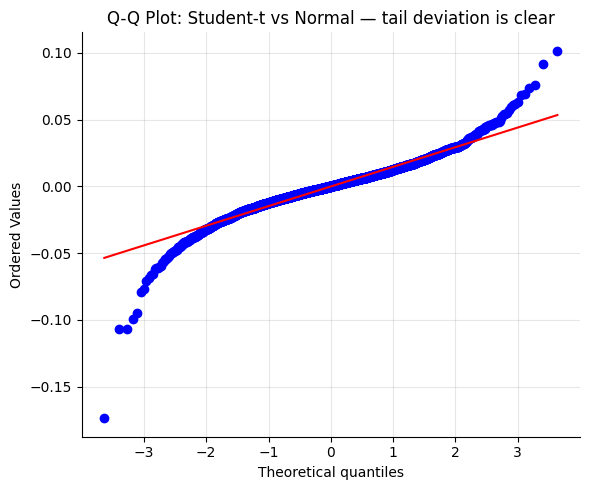

In [19]:
# Normality test: does the Normal assumption hold for simulated t-returns?
sample = r_t[:5000]

# Jarque-Bera test: H₀ = data is normally distributed
jb_stat, jb_p = stats.jarque_bera(sample)
skewness = stats.skew(sample)
excess_kurt = stats.kurtosis(sample)  # excess kurtosis

print("Normality check on Student-t sample (n=5,000):")
print(f"  Skewness        : {skewness:+.4f}  (Normal: 0)")
print(f"  Excess kurtosis : {excess_kurt:+.4f}  (Normal: 0)")
print(f"  Jarque-Bera stat: {jb_stat:.2f}")
print(f"  p-value         : {jb_p:.2e}")
print(f"  Reject normality: {jb_p < 0.05}")

# Q-Q plot
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(sample, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: Student-t vs Normal — tail deviation is clear")
plt.tight_layout()
plt.show()

---
## Summary

| Concept | Key takeaway for quant finance |
|---|---|
| Bayes' theorem | Rare events remain rare even with a good signal — base rates matter |
| Log-normality | Asset *prices* are modelled as log-normal; *log-returns* are approximately Normal |
| Fat tails / kurtosis | Real returns are leptokurtic — Normal VaR systematically underestimates tail risk |
| Correlation | Measures *linear* dependence only; tail co-movement requires copula or other models |
| Portfolio variance | $\mathbf{w}^\top \Sigma \mathbf{w}$ — diversification benefit vanishes as $\rho \to 1$ |
| CLT | Justifies normal approximations for sums; breaks down for infinite-variance distributions |
| MLE | The standard estimation framework; efficient asymptotically |
| t-test / p-value | Evaluate statistical significance of strategy returns; beware multiple testing |
| VaR vs CVaR | CVaR is coherent and captures severity, not just threshold of tail losses |